<a href="https://colab.research.google.com/github/Rufidatul726/6thSemester/blob/temp/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
#2 Exercise 2. Use PyDP to train differential private logistic regression models for predicting the income attribute
#in the clean dataset in Ex.1. The income attribute has two values <=50K and >50K. Compare the accuracy of
#the models with varying privacy budget ε in {0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5}. Note: You can use any
#Python tool for differential privacy and any mechanism for training models. However, you should include
#enough detail about running your code in your submission

!pip install python-dp

In [76]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from pydp.algorithms.laplacian import BoundedMean, BoundedSum, Count, Max, Min

In [77]:
# Load the data
df = pd.read_csv('adult.csv')

In [78]:
# Drop irrelevant columns
df = df.drop(['fnlwgt', 'education', 'capital-gain', 'capital-loss', 'native-country'], axis=1)

# Convert categorical columns to numeric
df['workclass'] = df['workclass'].astype('category').cat.codes
df['marital-status'] = df['marital-status'].astype('category').cat.codes
df['occupation'] = df['occupation'].astype('category').cat.codes
df['relationship'] = df['relationship'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['gender'] = df['gender'].astype('category').cat.codes
df['income'] = df['income'].astype('category').cat.codes

# Fill missing values in age with mean
df['age'] = df['age'].fillna(df['age'].mean())

In [79]:
# Define privacy budgets
epsilons = [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5]

In [80]:
# Split the data into X and y
X = df.drop('income', axis=1)
y = df['income']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
# Create a list to store the accuracy scores
accuracy_scores = []
new_age = []
new_hours_per_week=[]

In [82]:
# Loop over the privacy budgets
for epsilon in epsilons:
    # Create BoundedMean object for age
    age_mean = BoundedMean(epsilon= epsilon, lower_bound= 0, upper_bound= 100)

    # Create BoundedSum object for hours-per-week
    hours_sum = BoundedSum(epsilon= epsilon, lower_bound= 0, upper_bound= 100)

    # Add noise to age column
    for x in X_train['age']:
        age_mean.reset()
        new_age.append(age_mean.result(x))

    X_train['age'] = new_age
    new_age=[]

    for xq in X_test['age']:
        age_mean.reset()
        new_age.append(age_mean.result(xq))

    X_test['age'] = new_age
    new_age=[]

    # Add noise to hours-per-week column

    for xw in X_train['hours-per-week']:
        hours_sum.reset()
        new_age.append(hours_sum.result(xw))

    X_train['hours-per-week'] = new_age
    new_age=[]

    for xe in X_test['hours-per-week']:
        hours_sum.reset()
        new_age.append(hours_sum.result(xe))

    X_test['hours-per-week'] = new_age
    new_age=[]

    # Create and fit logistic regression model
    log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
    log_reg.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = log_reg.predict(X_test)

    # Calculate and print the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f'The accuracy of the logistic regression model with epsilon = {epsilon} is {accuracy:.3f}')

The accuracy of the logistic regression model with epsilon = 0.0001 is 0.766
The accuracy of the logistic regression model with epsilon = 0.001 is 0.765
The accuracy of the logistic regression model with epsilon = 0.01 is 0.783
The accuracy of the logistic regression model with epsilon = 0.1 is 0.787
The accuracy of the logistic regression model with epsilon = 0.2 is 0.786
The accuracy of the logistic regression model with epsilon = 0.3 is 0.784
The accuracy of the logistic regression model with epsilon = 0.4 is 0.781
The accuracy of the logistic regression model with epsilon = 0.5 is 0.783


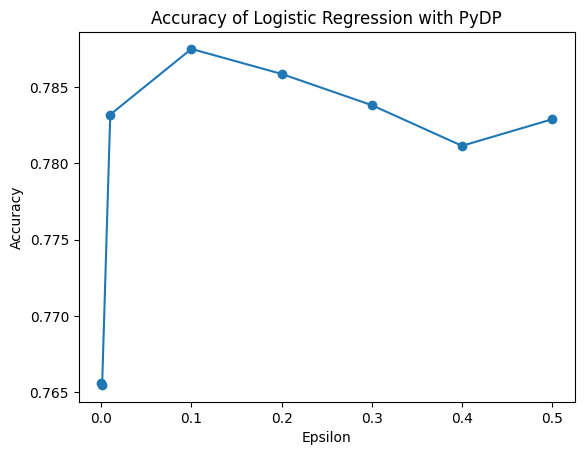

In [83]:
# Plot the accuracy scores against the privacy budgets
import matplotlib.pyplot as plt
plt.plot(epsilons, accuracy_scores, marker='o')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy of Logistic Regression with PyDP')
plt.show()
